In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
DATA_PATH = "Dry_Bean_Dataset/" 

train_df = pd.read_csv(DATA_PATH + "dry_bean_train.csv") 
test_df = pd.read_csv(DATA_PATH + "dry_bean_test.csv")

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

Train shape: (10834, 17)
Test shape: (2709, 17)


In [3]:
target = "class"

X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

In [6]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_reg = LogisticRegression(random_state=42, max_iter=1000)

log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [14]:
print(f"LOGISTIC REGRESSION")
print(f"Accurary: {accuracy_score(y_test, y_pred_log):.4f}")
print("\nBảng phân loại:")
print(classification_report(y_test, y_pred_log))

print(f"KNN")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print("\nBảng phân loại:")
print(classification_report(y_test, y_pred_knn))


LOGISTIC REGRESSION
Accurary: 0.9192

Bảng phân loại:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709

KNN
Accuracy: 0.9155

Bảng phân loại:
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.88      0.90       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.90      0.95      0.92       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.93      0

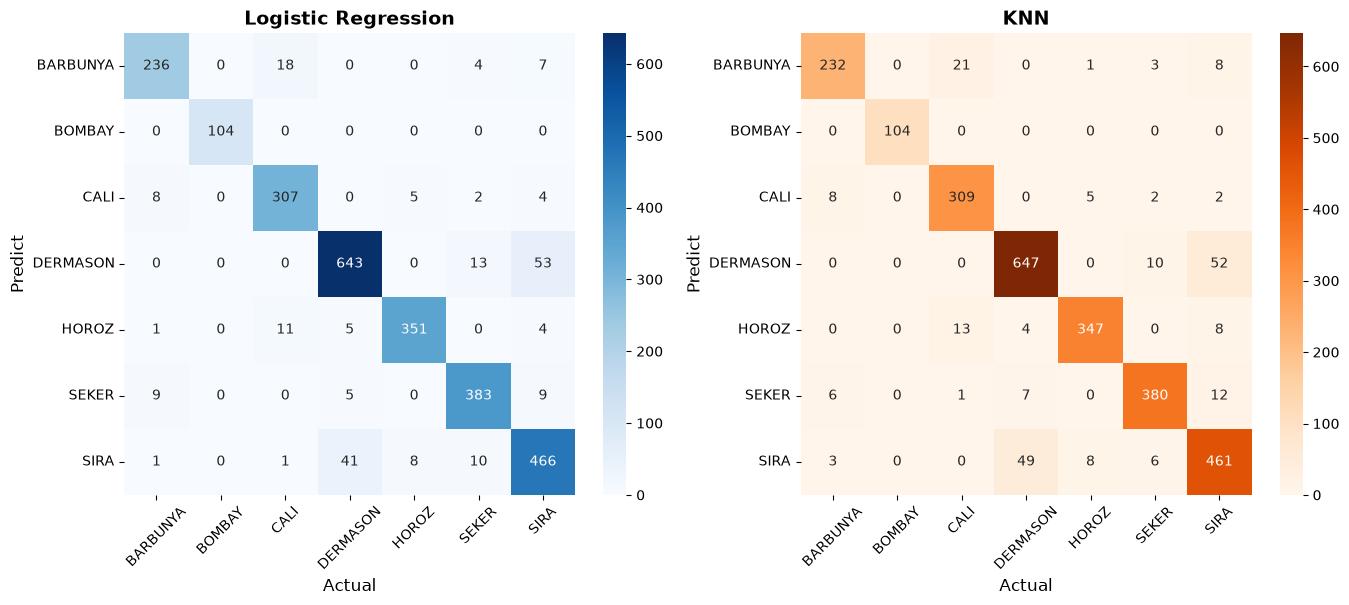

In [19]:
labels = log_reg.classes_

cm_log = confusion_matrix(y_test, y_pred_log)
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title("Logistic Regression", fontsize=14, fontweight="bold")
axes[0].set_ylabel('Predict', fontsize=12)
axes[0].set_xlabel('Actual', fontsize=12)

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title("KNN", fontsize=14, fontweight="bold")
axes[1].set_xlabel('Actual', fontsize=12)
axes[1].set_ylabel('Predict', fontsize=12)

for ax in axes:
    ax.tick_params(axis='x', rotation=45)


